<a href="https://colab.research.google.com/github/kenichiy19/1CCPK-MLAM/blob/main/Sprints/2026_1/MLAM_-_SPRINT_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Biblioteca**

In [17]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# **Código**

## Probabilidade acima da Mediana

In [15]:
df = pd.read_excel('ev_charging_patterns.xlsx')

variavel = 'Charging Duration (hours)'

mediana = df[variavel].median()
media = df[variavel].mean()
desvio_padrao = df[variavel].std()

probabilidade = 1 - stats.norm.cdf(mediana, media, desvio_padrao)

if probabilidade <= 0.10:
  classificacao = "Raro"
elif probabilidade < 0.50:
  classificacao = "Pouco provável"
elif probabilidade <= 0.9:
  classificacao = "Provável"
else:
  classificacao = "Quase certo"

print(f"Mediana: {mediana:.4f}")
print(f"Probabilidade de valores acima da mediana: {probabilidade * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Mediana: 2.2581
Probabilidade de valores acima da mediana: 50.42%
Classificação do evento: Provável


## Probabilidade no intervalo (média ± 2 desvios-padrão)

In [16]:
limite_inferior = media - (2 * desvio_padrao)
limite_superior = media + (2 * desvio_padrao)

prob_intervalo = stats.norm.cdf(limite_superior, media, desvio_padrao) - stats.norm.cdf(limite_inferior, media, desvio_padrao)

if prob_intervalo <= 0.10:
    classificacao = "Raro"
elif prob_intervalo < 0.50:
    classificacao = "Pouco provável"
elif prob_intervalo <= 0.90:
    classificacao = "Provável"
else:
    classificacao = "Quase certo"

print(f"Média: {media:.4f}")
print(f"Desvio-Padrão: {desvio_padrao:.4f}")
print(f"Limites do Intervalo: de {limite_inferior:.4f} a {limite_superior:.4f} horas")
print(f"Probabilidade no intervalo: {prob_intervalo * 100:.2f}%")
print(f"Classificação do evento: {classificacao}")

Média: 2.2694
Desvio-Padrão: 1.0610
Limites do Intervalo: de 0.1473 a 4.3915 horas
Probabilidade no intervalo: 95.45%
Classificação do evento: Quase certo


## Modelagem com Regressão Linear

### Investigação das Relações Entre as Variáveis Numéricas

In [24]:
colunas_numericas = df.select_dtypes(include=['float64', 'int64'])
matriz_corr = colunas_numericas.corr()

print("Matriz de Correlação Global:")
display(matriz_corr)

Matriz de Correlação Global:


,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years)
Battery Capacity (kWh),1.000000,0.000323,-0.024824,0.015866,-0.000492,-0.072148,-0.011512,-0.041194,-0.036411,0.037673
Energy Consumed (kWh),0.000323,1.000000,0.028369,-0.042610,-0.007787,-0.013413,0.000601,-0.027948,-0.018509,0.017105
Charging Duration (hours),-0.024824,0.028369,1.000000,-0.013460,0.015902,-0.026016,0.006958,0.023644,-0.049575,0.001111
Charging Rate (kW),0.015866,-0.042610,-0.013460,1.000000,-0.000853,-0.019289,-0.018705,0.032209,0.012818,-0.050523
Charging Cost (USD),-0.000492,-0.007787,0.015902,-0.000853,1.000000,-0.008653,-0.063175,-0.008528,0.059864,-0.006487
State of Charge (Start %),-0.072148,-0.013413,-0.026016,-0.019289,-0.008653,1.000000,-0.021410,-0.023494,0.037750,0.016635
State of Charge (End %),-0.011512,0.000601,0.006958,-0.018705,-0.063175,-0.021410,1.000000,0.025574,0.022027,0.015671
Distance Driven (since last charge) (km),-0.041194,-0.027948,0.023644,0.032209,-0.008528,-0.023494,0.025574,1.000000,-0.023733,-0.031498
Temperature (°C),-0.036411,-0.018509,-0.049575,0.012818,0.059864,0.037750,0.022027,-0.023733,1.000000,0.026410
Vehicle Age (years),0.037673,0.017105,0.001111,-0.050523,-0.006487,0.016635,0.015671,-0.031498,0.026410,1.000000


In [25]:
pares_correlacao = matriz_corr.unstack().reset_index()
pares_correlacao.columns = ['Variavel_1', 'Variavel_2', 'Correlação']

pares_correlacao = pares_correlacao[pares_correlacao['Variavel_1'] != pares_correlacao['Variavel_2']]
pares_correlacao['Corr_Abs'] = pares_correlacao['Correlação'].abs()
pares_correlacao = pares_correlacao.drop_duplicates(subset=['Corr_Abs']).sort_values(by='Corr_Abs', ascending=False)

print("Top 5 maiores correlações encontradas na base:")
display(pares_correlacao.head(10))

Top 5 maiores correlações encontradas na base:


,Variavel_1,Variavel_2,Correlação,Corr_Abs
5,Battery Capacity (kWh),State of Charge (Start %),-0.072148,0.072148
46,Charging Cost (USD),State of Charge (End %),-0.063175,0.063175
48,Charging Cost (USD),Temperature (°C),0.059864,0.059864
39,Charging Rate (kW),Vehicle Age (years),-0.050523,0.050523
28,Charging Duration (hours),Temperature (°C),-0.049575,0.049575
13,Energy Consumed (kWh),Charging Rate (kW),-0.042610,0.042610
7,Battery Capacity (kWh),Distance Driven (since last charge) (km),-0.041194,0.041194
58,State of Charge (Start %),Temperature (°C),0.037750,0.037750
9,Battery Capacity (kWh),Vehicle Age (years),0.037673,0.037673
8,Battery Capacity (kWh),Temperature (°C),-0.036411,0.036411


### Implementação do Modelo de Regressão Linear

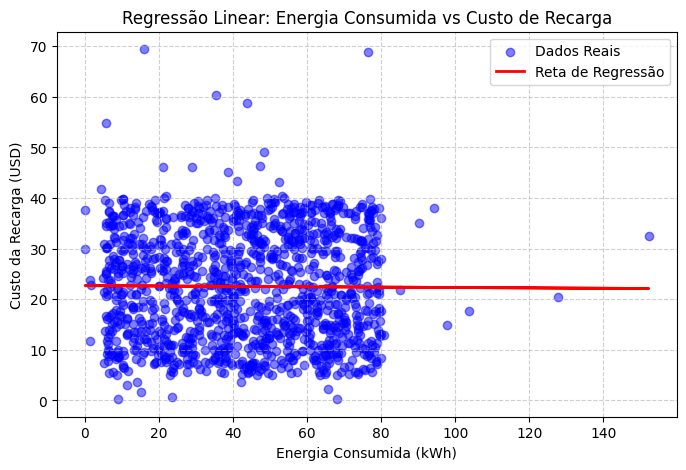

Coeficiente Angular (Inclinação): -0.0037
Coeficiente Linear (Interseção): 22.6866
Coeficiente de Determinação (R²): 0.000061


In [20]:
dados_limpos = df[['Energy Consumed (kWh)', 'Charging Cost (USD)']].dropna()

X = dados_limpos[['Energy Consumed (kWh)']]
y = dados_limpos['Charging Cost (USD)']

modelo = LinearRegression()
modelo.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Dados Reais')
plt.plot(X, modelo.predict(X), color='red', linewidth=2, label='Reta de Regressão')

plt.title('Regressão Linear: Energia Consumida vs Custo de Recarga')
plt.xlabel('Energia Consumida (kWh)')
plt.ylabel('Custo da Recarga (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Coeficiente Angular (Inclinação): {modelo.coef_[0]:.4f}")
print(f"Coeficiente Linear (Interseção): {modelo.intercept_:.4f}")
print(f"Coeficiente de Determinação (R²): {modelo.score(X, y):.6f}")

### **Interpretação (Item C)**

**1. Coeficiente Angular (Interseção)**:

O valor obtido foi de 22.6866. Na teoria da regressão, isso indica que se a energia consumida fosse zero (0 kWh), o modelo estimaria um custo inicial de aproximadamente $22.69 USD para a recarga.


**2. Coeficiente Angular (Inclinação)**:

O valor obtido foi de -0.0037. Isso significa que para cada 1 kWh adicional consumido, o custo da recarga varia (neste caso, tem uma queda microscópica) em cerca de 0,3 centavos de dólar. Como o valor é extremamente próximo de zero, ele indica que a inclinação da reta é praticamente horizontal.


**3. Coeficiente de Determinação**:

O valor obtido foi de 0.000061 (ou cerca de 0,006%). Este é o dado mais importante da análise: ele demonstra que a variação na quantidade de energia consumida não explica a variação no custo da recarga.


**Conclusão**:

Gráfica e estatisticamente, a reta de regressão horizontal e o R² nulo evidenciam que não há correlação linear entre a energia consumida (kWh) e o custo da recarga (USD) nesta base de dados específica. Portanto, o modelo linear gerado não possui capacidade preditiva confiável para este par de variáveis, sugerindo que o sistema de cobrança dos dados analisados provavelmente obedece a outras regras (ou tarifas fixas) independentes do volume de kWh consumido.

Vale destacar que o Coeficiente Linear indicou um custo inicial de $22.69 USD quando a energia consumida é zero. No entanto, do ponto de vista prático e de negócio, este valor não faz sentido físico — ninguém pagaria por energia não consumida. Esse resultado evidencia, mais uma vez, uma limitação do modelo linear para esta base: como não há correlação real entre as variáveis, a reta de regressão se comporta de maneira estática e horizontal, apenas refletindo a média geral dos custos da base, e não uma regra de cobrança real.

## Relação entre Estatística e Aprendizado de Máquina

**O papel da Estatística**: Nos Exercícios 01 e 02, utilizamos a estatística paramétrica (através da Distribuição Normal, média, desvio-padrão e funções de acumulada CDF) para compreender o comportamento univariado da duração das recargas, mapeando incertezas e calculando probabilidades exatas. Além disso, na primeira etapa do Exercício 03 (Investigação das Relações Entre as Variáveis Numéricas), a estatística atuou como ferramenta de diagnóstico exploratório por meio da matriz de correlação global, revelando que as variáveis do dataset real apresentam correlações lineares muito fracas ou próximas de zero.

**O papel do Aprendizado de Máquina**: Na segunda etapa do Exercício 03, avançamos para o aprendizado de máquina supervisionado por meio da Regressão Linear. Enquanto a estatística exploratória mapeou a ausência de forte associação prévia, o modelo de ML buscou testar formalmente a existência de um padrão preditivo linear entre as dimensões analisadas.

**Conclusão**: Os resultados se complementam e revelam uma verdade fundamental da ciência de dados: modelos preditivos dependem diretamente da estrutura e da correlação real dos dados. A investigação estatística preliminar antecipou o comportamento do modelo, e a ausência de correlação (comprovada por um R² praticamente nulo e coeficientes estáticos) demonstrou que algoritmos de aprendizado de máquina não conseguem criar previsões precisas quando a base de dados não apresenta uma relação linear real. Assim, a análise estatística inicial revelou a ausência de relação linear nos dados, o que explica de forma clara o baixo desempenho preditivo do modelo de aprendizado de máquina.